# Overview of the Energy Balance Model (EBM)


## Objectives
- Demonstrate **how to use the model**.
- Highlight its strengths, particularly its ability to take **seasonal cycles** into account.
- Describe the **pre-industrial climate**, which will serve as our baseline.

## Main equation
The model is one-dimensional in latitude, with heat transfer based on Budyko's formulation.  
Its main equation can be written as,

$C_i \frac{\partial T_i}{\partial t} = S_i (1 - \alpha(T_i)) - R_\uparrow(T_i) - F(T_i)$  

where $i$ refers to a band of latitude and with $C_i$ the heat capacity, $S_i$ the incident solar flux, $R_\uparrow$ the outgoing radiative flux and $F(T_i)$ the meridional heat transfer.


For more details on the theoretical model and its implementation, see the [project report](https://github.com/louiscleen/energy-balance-model/blob/main/energy-balance-model.pdf)

Author: Louis Cleen  
Academic year: 2025–2026   

---

## Getting started with the model
To begin, we import the libraries we'll need, as well as the `EBM1DBudyko` class from the `ebm1d` module. This class is self-contained (i.e., it includes the integration method); we only need a function to load the configuration file, which contains the parameters, and a function to load a dataset. The dataset must include, for each latitude band, the land fraction, cloud fraction, and initial temperature. These two functions are also provided by the module.

In [38]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from ebm1d import EBM1DBudyko
from ebm1d import load_config
from ebm1d import load_input_data

ROOT_DIR = Path.cwd().parent

plt.style.use(ROOT_DIR / ".mplstyle")

# Setting up the results directory where the figures will be saved. 
results_dir = ROOT_DIR / "results" / "exploration"
results_dir.mkdir(parents=True, exist_ok=True)

# Loading the configuration containing the model parameters and the input dataset
# The dataset is loaded using the load_input_data function which requires its file path (specified in the configuration file)
# and the number of rows to read, i.e., the number of latitudes in the model.
config = load_config(ROOT_DIR / "configs" / "default.toml")
inputs = load_input_data(config.input.dataset, config.model.n_lat)
print("Configuration loaded successfully.")

Configuration loaded successfully.


The entire model is defined in the `EBM1DBudyko` class.
It can be used with either annualized or seasonal solar flux data. To select a state, simply change the “seasonal” boolean parameter in the configuration file.  

Please note that you can override this parameter by passing it as an argument to the class in order to use the same configuration file for both annual and seasonal models.  

Let's create, for example, a seasonal and annualized model:

In [39]:
ebm_seasonal = EBM1DBudyko(config, inputs)
ebm_annual_mean = EBM1DBudyko(config, inputs, seasonal=False)

Initializing the 1D EBM with 18 latitude band and seasonal insolation = True
Initializing the 1D EBM with 18 latitude band and seasonal insolation = False


To integrate the model, use the method `integrate()`.  

To operate, it uses a list of initial temperatures (by latitude band), a time step and a number of years to integrate over; theses inputs are defined in the configuration file.  
You can override them by providing `T0`, `dt_days` and `n_years`. In addition, the argument `stop_at_convergence` (which is false by default) allows you to stop the integration when the maximum temperature change is below `tol`. Finally, `min_years` allows you to force the model to integrate over a minimum number of years.  

It returns a tuple (t_days, T_history, info) where:  
* t_days is the array of time points in days            
* T_history is the array of temperature profiles by latitude at each time point
* info is a dictionary with additional information about the integration (converged or not, number of steps per year and the total time in years)

For more information, use `help(EBM1DBudyko.integrate)`

In [40]:
t_days, T_history, info = ebm_seasonal.integrate(
    stop_at_convergence=False,
    n_years=20,
    dt_days=1
)

# The following results primarily concern the seasonal model. To distinguish between the variables, 
# we add the suffix _a_m when they refer to the annualized model
t_days_a_m, T_history_a_m, info_a_m = ebm_annual_mean.integrate(
    stop_at_convergence=True,
    min_years=5,
    dt_days=1
)

# Let's display the convergence information for both integrations

def print_convergence_info(model, info):
    if info['converged']:
        print(f"{model} has converged. Final state reached at t = {info['t_final_years']} " 
              f"years after {info['steps_per_year'] * info['t_final_years']} steps.")
    else:
        print(f"{model} has not converged !")

print_convergence_info("Seasonal EBM", info)
print_convergence_info("Annualized EBM", info_a_m)

Seasonal EBM has converged. Final state reached at t = 20.0 years after 7300.0 steps.
Annualized EBM has converged. Final state reached at t = 21.0 years after 7665.0 steps.



---

## Results
Now, we are going to use the integration data to plot various results, through which we will illustrate some methods and possibilities of the class.

### Latitudinal temperature profile at equilibrium
Here, we compare the mean surface temperature at equilibrium between the annualized model and the seasonalized model

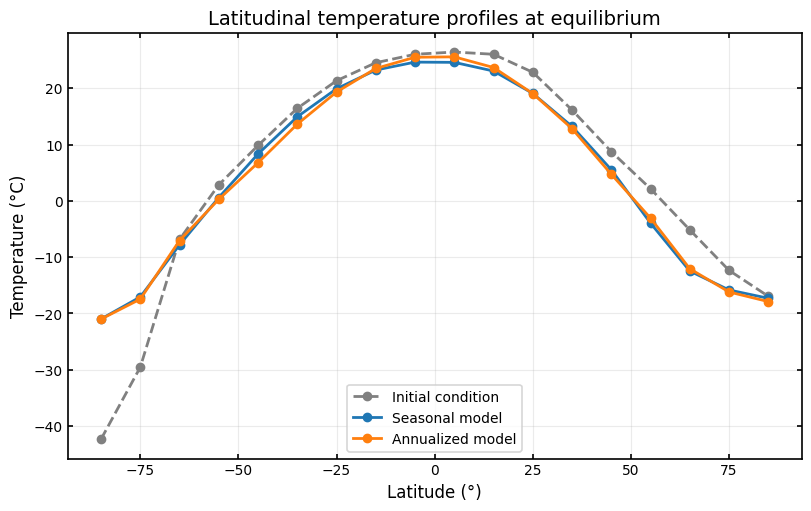

In [41]:
# Extracting the temperature history of last year
steps_per_year = info['steps_per_year']
# For clarity, we assume that the number of steps per year is the same for both models
# which is the case when they have the same time step.
T_last_year = T_history[-steps_per_year:]
T_last_year_a_m = T_history_a_m[-steps_per_year:]

# Mean temperature profile of last year 
T_last_year_mean = T_last_year.mean(axis=0)
T_last_year_a_m_mean = T_last_year_a_m.mean(axis=0)

# Latitude centers in degrees
lat_centers_deg = ebm_seasonal.lat_centers_deg

# Plotting the initial and final temperature profiles in °C
fig, ax = plt.subplots()
ax.plot(lat_centers_deg, ebm_seasonal.input_data.T0 - 273.15, label="Initial condition", ls='--', marker='o', color='gray')
ax.plot(lat_centers_deg, T_last_year_mean - 273.15, label="Seasonal model", marker='o')
ax.plot(lat_centers_deg, T_last_year_a_m_mean - 273.15, label="Annualized model", marker='o')
ax.set_xlabel("Latitude (°)")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Latitudinal temperature profiles at equilibrium")
ax.legend(loc='lower center')
fig.savefig(results_dir / "temperature_profiles.png")
plt.show()

### Global temperature history
Let's examine how global temperatures have changed over time. This will illustrate the `global_temperature` method, which computes a surface-area-weighted average across latitude bands.  
It also allows us to verify the model's convergence.  
Next, we compute the global mean temperature over the last year.

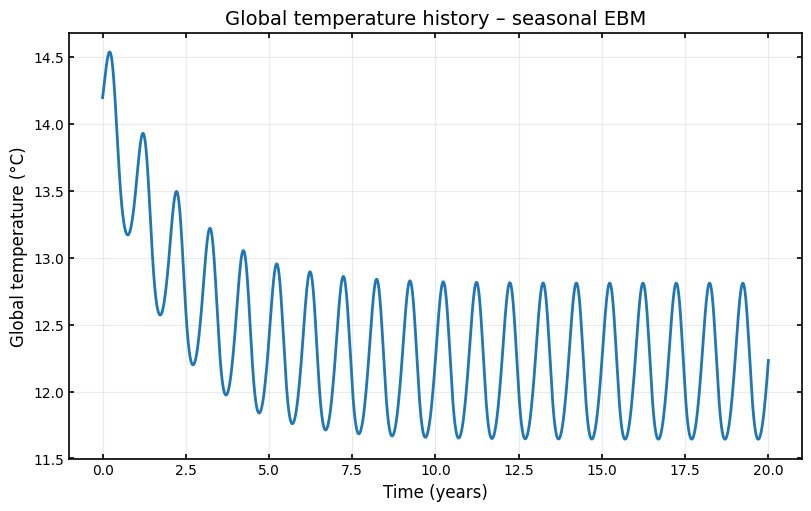

Global mean temperature of the last year: 12.18 °C


In [42]:
# Plotting the global temperature history in °C
T_global = ebm_seasonal.global_temperature(T_history)
YEAR_IN_DAYS = ebm_seasonal.YEAR_IN_DAYS 
# Note that .YEAR_IN_DAYS is a class attribute of EBM1DBudyko (i.e., not instance-specific), so it can also be accessed directly from the class.
t_years = t_days / YEAR_IN_DAYS

fig, ax = plt.subplots()
ax.plot(t_years, T_global - 273.15)
ax.set_xlabel("Time (years)")
ax.set_ylabel("Global temperature (°C)")
ax.set_title("Global temperature history – seasonal EBM")
fig.savefig(results_dir / "global_temperature_history.png")
plt.show()

# Calculating and displaying the global mean temperature of the last year
T_global_mean_last_year = T_global[-steps_per_year:].mean()
print(f"Global mean temperature of the last year: {T_global_mean_last_year - 273.15:.2f} °C")

### Temperature history at different latitudes
We will plot the temperature history for northern latitudes over the last two years. We assume that the model uses 18 latitude bands.
Next, we calculate the minimum and maximum temperatures, as well as their position within the year.  

As you can see, the system responds with some latency (remember that the summer solstice is on June 21 in the Northern Hemisphere). This is due to the thermal capacity, which can be adjusted in the configuration file. A low value results in a more responsive system, while a higher value simulates a system that mixes a deeper layer of the ocean.

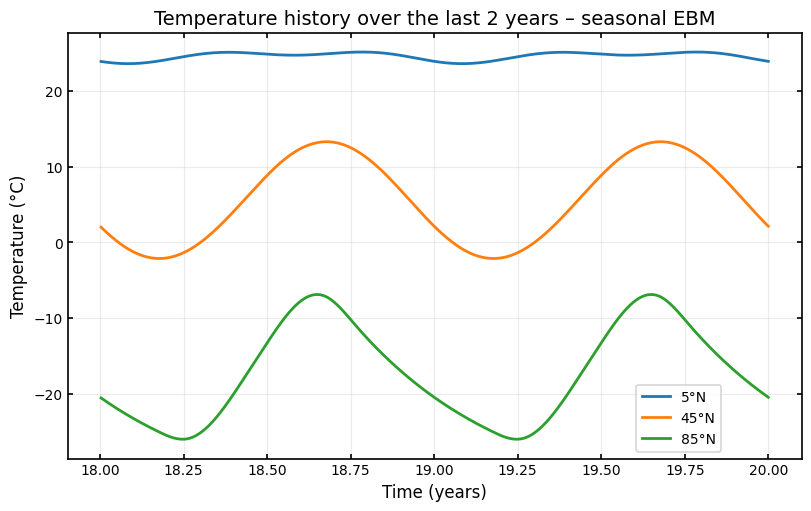

Latitude   | Min (°C)   | at Day     | Max (°C)   | at Day    
------------------------------------------------------------
5°N        | 23.62      | 31         | 25.15      | 286       
45°N       | -2.13      | 65         | 13.30      | 247       
85°N       | -26.01     | 90         | -6.89      | 237       


In [43]:
# We use a dictionary to link the latitude to its index
target_lats = {
    '5°N': 9,
    '45°N': 13,
    '85°N': 17
}
indices = list(target_lats.values())
labels = list(target_lats.keys())

fig, ax = plt.subplots()
ax.plot(t_years[-steps_per_year*2:], T_history[-steps_per_year*2:, indices] - 273.15, label=labels)
ax.set(xlabel="Time (years)", 
       ylabel="Temperature (°C)", 
       title="Temperature history over the last 2 years – seasonal EBM")
ax.legend(bbox_to_anchor=(0.9, 0), loc='lower right')
fig.savefig(results_dir / "temperature_history_target_latitudes.png")
plt.show()

# Statistical analysis of the last year for the target latitudes
print(f"{'Latitude':<10} | {'Min (°C)':<10} | {'at Day':<10} | {'Max (°C)':<10} | {'at Day':<10}")
print("-" * 60)

for label, idx in target_lats.items():
    
    T_subset = T_history[-steps_per_year:, idx] - 273.15
    time_subset = t_days[-steps_per_year:] % YEAR_IN_DAYS
    
    # Min and max indices
    imin, imax = np.argmin(T_subset), np.argmax(T_subset)
    
    print(f"{label:<10} | {T_subset[imin]:<10.2f} | {time_subset[imin]:<10.0f} | {T_subset[imax]:<10.2f} | {time_subset[imax]:<10.0f}")

Another way to represent the data is to use a heatmap:

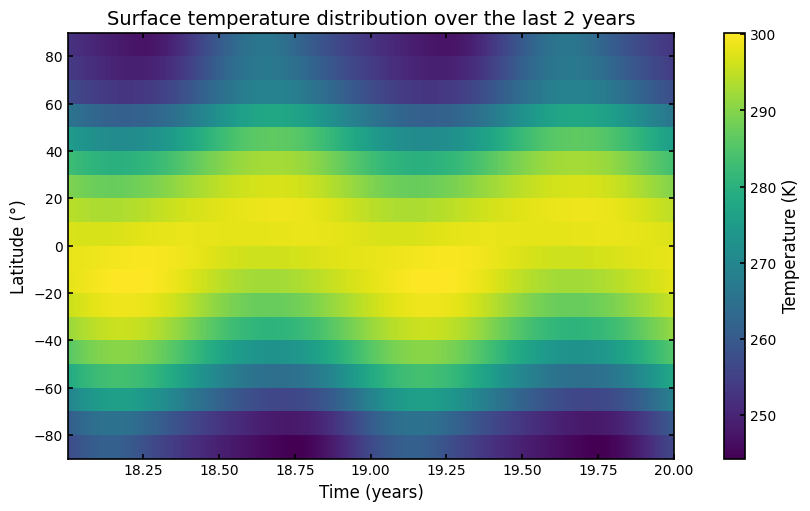

In [44]:
fig, ax = plt.subplots()
im = ax.pcolormesh(
    t_years[-steps_per_year*2:],
    lat_centers_deg,
    T_history[-steps_per_year*2:].T,
    shading='auto',
)   
ax.set_xlabel("Time (years)")
ax.set_ylabel("Latitude (°)")
ax.set_title("Surface temperature distribution over the last 2 years")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Temperature (K)")
ax.grid(False)
fig.savefig(results_dir / "temperature_distribution_last_2_years.png")
plt.show()

### Latitudinal profile of albedo
Here we illustrate various methods for recovering albedo and its components

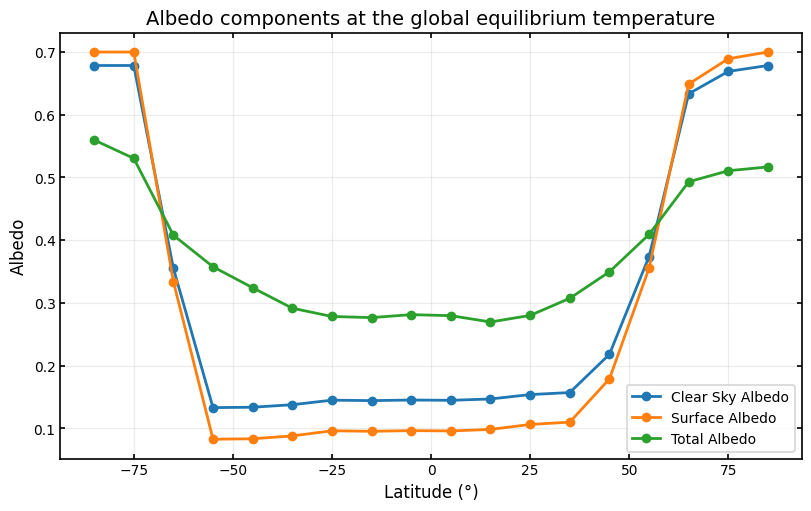

In [45]:
# Albedo components at the global equilibrium temperature
albedo_clear_sky = ebm_seasonal.compute_albedo_clear_sky(T_last_year_mean)
albedo_surf = ebm_seasonal.compute_albedo_surf(T_last_year_mean)
albedo = ebm_seasonal.compute_albedo(T_last_year_mean)

fig, ax = plt.subplots()
ax.plot(lat_centers_deg, albedo_clear_sky, label="Clear Sky Albedo", marker='o')
ax.plot(lat_centers_deg, albedo_surf, label="Surface Albedo", marker='o')
ax.plot(lat_centers_deg, albedo, label="Total Albedo", marker='o')
ax.set_xlabel("Latitude (°)")
ax.set_ylabel("Albedo")
ax.set_title("Albedo components at the global equilibrium temperature")
ax.legend()
fig.savefig(results_dir / "albedo_components.png")
plt.show()

### Dataset contents
We will present the contents of the dataset required by the model. Specifically, the land fraction and the cloud fraction.

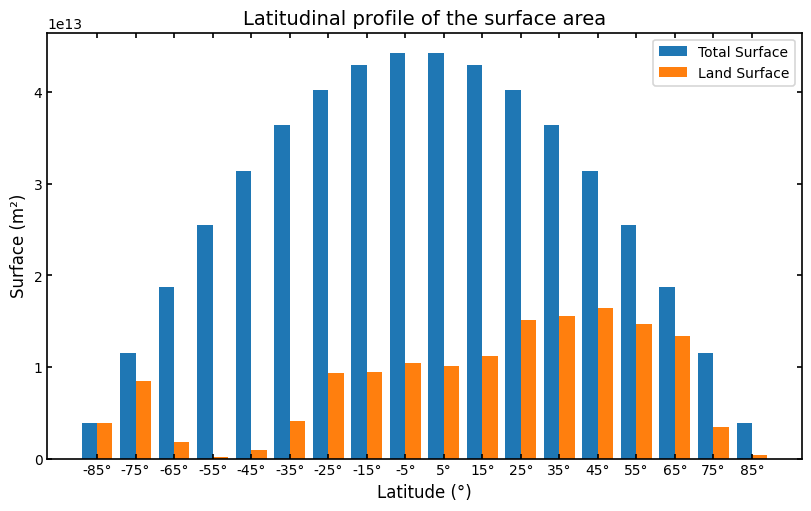

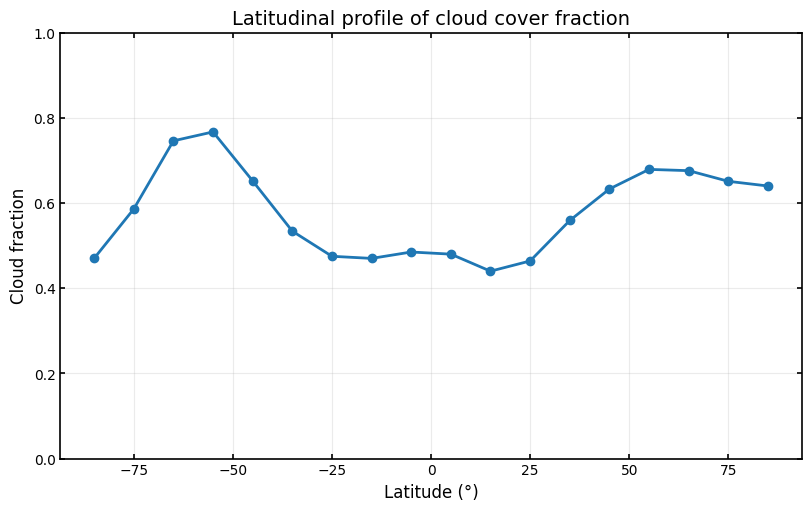

In [46]:
# Latitudinal profile of the surface area
area = ebm_seasonal.area # Surface area of each latitude band calculated by the model
area_land = area * ebm_seasonal.input_data.f_land
width = 0.4
x = np.arange(len(lat_centers_deg))

fig, ax = plt.subplots()
ax.bar(x - width/2, area, width=width, label="Total Surface")
ax.bar(x + width/2, area_land, width=width, label="Land Surface")
ax.set_xticks(x)
ax.set_xticklabels([f"{lat:.0f}°" for lat in lat_centers_deg])
ax.set_xlabel("Latitude (°)")
ax.set_ylabel("Surface (m²)")
ax.set_title("Latitudinal profile of the surface area")
ax.legend()
ax.grid(False)
fig.savefig(results_dir / "surface_area_profile.png")
plt.show()

# Latitudinal profile of the cloud fraction
f_cloud = ebm_seasonal.input_data.f_cloud

fig, ax = plt.subplots()
ax.plot(lat_centers_deg, f_cloud, marker='o')
ax.set_ylim(0, 1)
ax.set_xlabel("Latitude (°)")
ax.set_ylabel("Cloud fraction")
ax.set_title("Latitudinal profile of cloud cover fraction")
fig.savefig(results_dir / "cloud_fraction_profile.png")
plt.show()


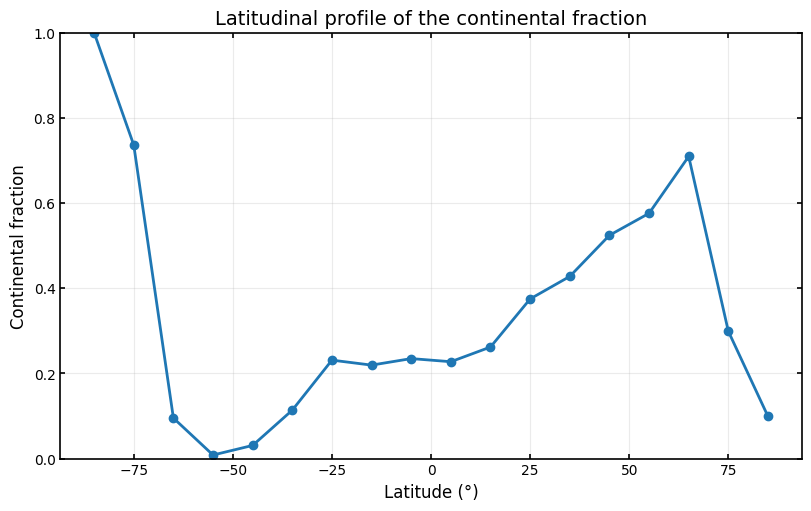

In [47]:
# Latitudinal profile of the land fraction
f_land = ebm_seasonal.input_data.f_land

fig, ax = plt.subplots()
ax.plot(lat_centers_deg, f_land, marker='o')
ax.set_ylim(0, 1)
ax.set_xlabel("Latitude (°)")
ax.set_ylabel("Continental fraction")
ax.set_title("Latitudinal profile of the continental fraction")
fig.savefig(results_dir / "land_fraction_profile.png")
plt.show()

### Solar flux distribution
We calculate the solar flux distribution factor for the annualized model. It can be seen that the approximation used by the model, which is based on Legendre polynomials, is in good agreement with the actual measurements.  

For the seasonal model, a heatmap provides a clearer visualization of the dependence on latitude and time. As it can be seen, the flux is fairly constant near the equator and reaches its maximum at the poles during the summer solstice (~June 21 in the Northern Hemisphere and ~December 21 in the Southern Hemisphere). 

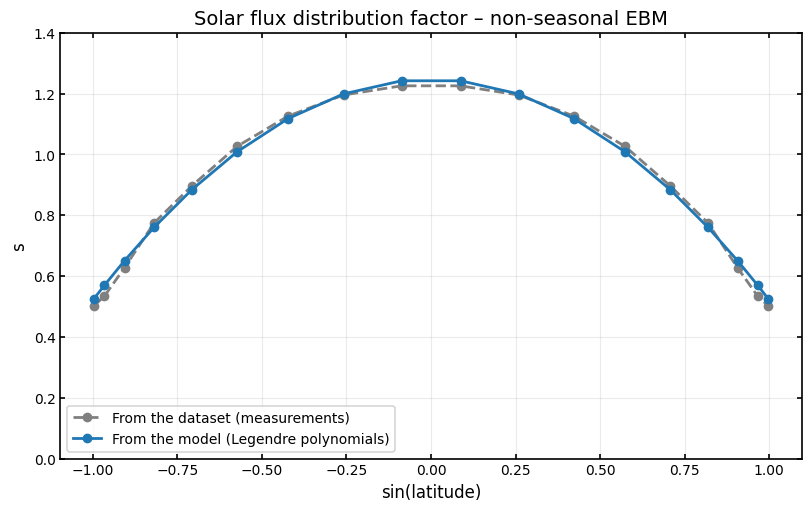

In [48]:
# Profile of the solar flux distribution factor "s" used in the non-seasonal EBM as a function of sin(latitude)
x = np.sin(ebm_seasonal.lat_centers_rad)

# The solar flux distribution factor "s" used in the non-seasonal EBM is calculated using a approximation 
# based on Legendre polynomials. More details can be found in the report.
s = ebm_annual_mean.get_solar_flux() / (1361/4) 
df_dataset = pd.read_csv(config.input.dataset, sep='\t')
s_dataset = df_dataset['S'] / (1361/4)

fig, ax = plt.subplots()
ax.plot(x, s_dataset, label="From the dataset (measurements)", ls='--', marker='o', color='gray')
ax.plot(x, s, label="From the model (Legendre polynomials)", marker='o')
ax.set_ylim(0, 1.4)
ax.set_xlabel("sin(latitude)")
ax.set_ylabel("s")
ax.set_title("Solar flux distribution factor – non-seasonal EBM")
ax.legend()
fig.savefig(results_dir / "solar_flux_distribution_factor.png")
plt.show()

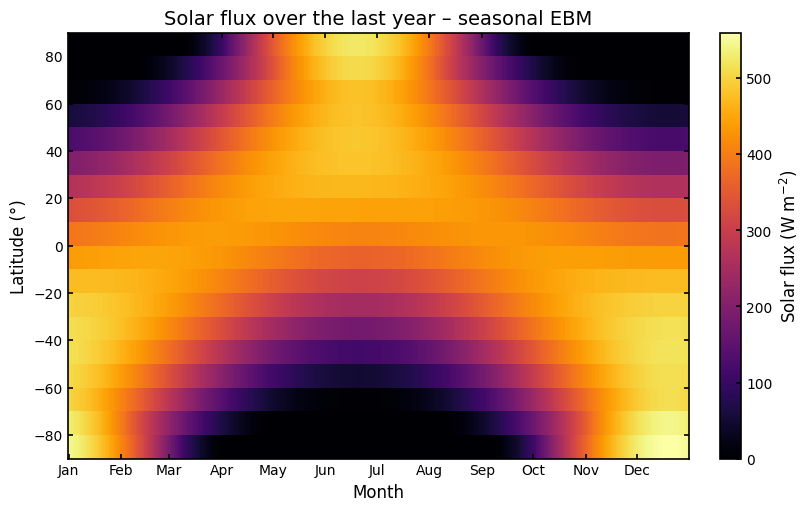

In [49]:
# In the case of the seasonal model, a very visual way to represent both the dependence 
# on latitude and on time of the solar flux is to create a heatmap.

# We extract the solar flux values for the last year of the seasonal model, which are stored in a 2D array
solar_flux_last_year = np.array([ebm_seasonal.get_solar_flux(day) for day in t_days[-steps_per_year:]])

# Approximate number of days in each month (considering a year of 365 days)
days_in_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
month_starts = np.cumsum([0] + days_in_month[:-1]) # We start from 0 to match the day counting
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots()
im = ax.pcolormesh(
    np.arange(0, YEAR_IN_DAYS, YEAR_IN_DAYS/steps_per_year),
    lat_centers_deg,
    solar_flux_last_year.T,
    shading='auto',
    cmap='inferno',
    vmin=0
)
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels)
ax.set_xlabel("Month")
ax.set_ylabel("Latitude (°)")
ax.set_title("Solar flux over the last year – seasonal EBM")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"Solar flux (W m$^{-2}$)")
ax.grid(False)
fig.savefig(results_dir / "solar_flux_last_year.png")
plt.show()

### Radiative flux and energy balance
The latitudinal profile of the absorbed solar flux and outgoing IR flux reveals that there is no balance between these two fluxes. This highlights the meridional transport of heat, which allows the absorbed flux to be re-emitted at higher latitudes.  
To verify that its calculation is correct, we will check if the energy transported along the latitudes is indeed conserved (the energy absorbed at one latitude necessarily comes from another latitude).

Next, we sort of plot the energy balance, that is, the net radiative power and the power of meridional heat transport. At equilibrium, the main equation of the model predicts that these fluxes will balance each other at every latitude, which is indeed what can be observed.  
Finally, to characterize this compensation, we will plot the meridional transport as a function of the net radiative flux. If the model has converged to equilibrium, we should find the identity function. This is what we observe, as confirmed by the linear fit.

In [50]:
# First, we compute all the fluxes that we will need for the following analysis. 
# This includes the meridional heat transport, absorbed solar flux, and outgoing IR flux.
F_flux_last_year = np.array([ebm_seasonal.compute_meridional_heat_transport(T) for T in T_last_year])
F_flux_mean = F_flux_last_year.mean(axis=0) 
F_power_mean = F_flux_mean * area

solar_flux_mean = solar_flux_last_year.mean(axis=0)
solar_flux_mean_absorbed = solar_flux_mean * (1 - ebm_seasonal.compute_albedo(T_last_year_mean))

IR_flux_last_year = np.array([ebm_seasonal.compute_outgoing_IR_flux(T) for T in T_last_year])
IR_flux_mean = IR_flux_last_year.mean(axis=0)

# The net flux sol - IR is the difference between the absorbed solar flux and the outgoing IR flux. 
sol_IR_net_flux_mean = solar_flux_mean_absorbed - IR_flux_mean
sol_IR_net_power_mean = sol_IR_net_flux_mean * area

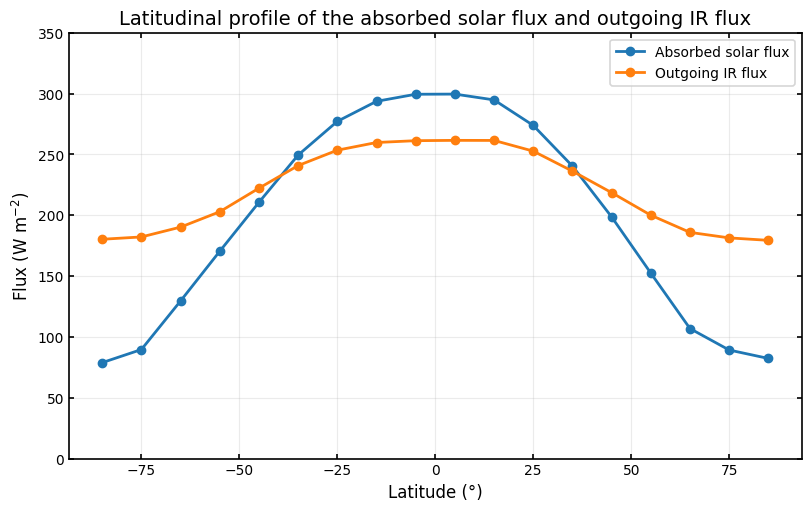

In [51]:
# Latitudinal profile of the absorbed solar flux and outgoing IR flux
fig, ax = plt.subplots()
ax.plot(lat_centers_deg, solar_flux_mean_absorbed, label="Absorbed solar flux", marker='o')
ax.plot(lat_centers_deg, IR_flux_mean, label="Outgoing IR flux", marker='o')
ax.set_ylim(0, 350)
ax.set_xlabel("Latitude (°)")
ax.set_ylabel(r"Flux (W m$^{-2}$)")
ax.set_title("Latitudinal profile of the absorbed solar flux and outgoing IR flux")
ax.legend()
fig.savefig(results_dir / "absorbed_solar_flux_outgoing_IR_flux.png")
plt.show()

In [52]:
# Conservation of energy transported along the latitude

# To avoid numerical noise, we use f_area instead of area. 
# It should give the same result since the the sum of energy is expected to be zero.
# Therefore we can divide the sum by the total surface area to get the global mean net flux, which should also be close to zero.
f_area = ebm_annual_mean.f_area 
T_global_last_year = T_global[-steps_per_year:]
sum = (T_last_year - T_global_last_year[:, np.newaxis]) @ f_area
energy_is_conserved = np.allclose(sum, 0.0, atol=1e-12) # We use a very small tolerance to check if the sum is effectively zero.

if energy_is_conserved:
    print("Energy was conserved everyday of the last year !")

# Note that 'sum = F_flux_last_year @ f_area' also gives the same result

Energy was conserved everyday of the last year !


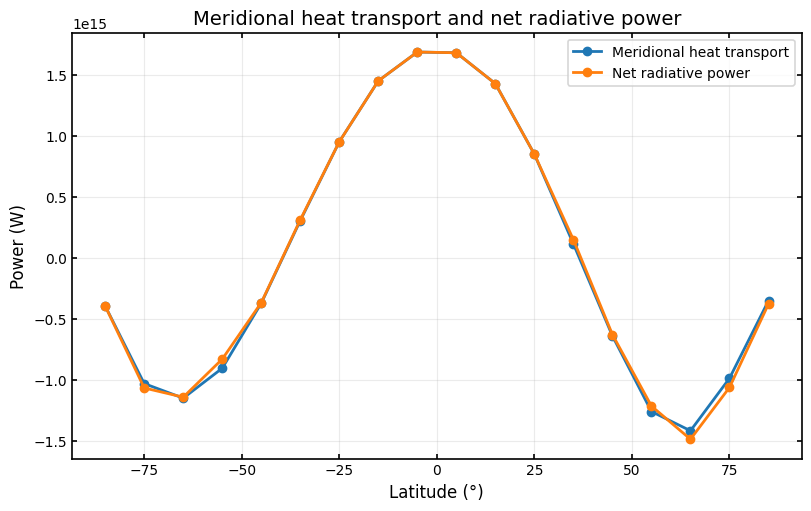

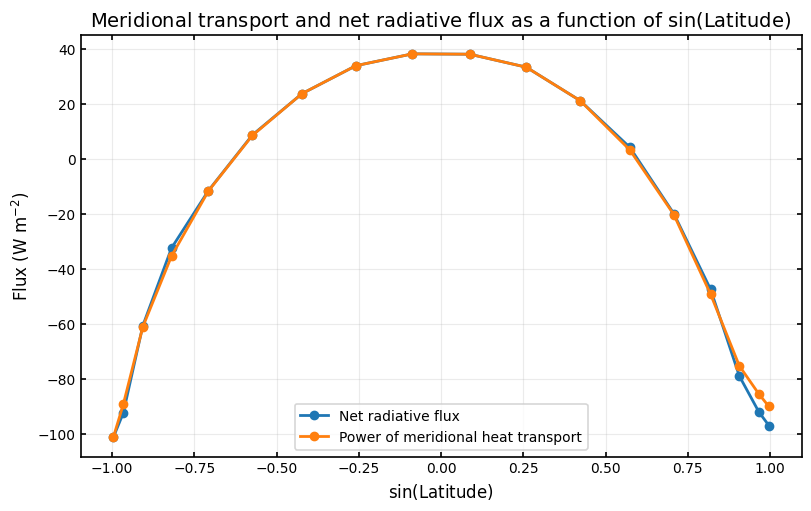

In [53]:
# Latitudinal profile of the meridional heat transport and net radiative power
fig, ax = plt.subplots()
ax.plot(lat_centers_deg, F_power_mean, label="Meridional heat transport", marker='o')
ax.plot(lat_centers_deg, sol_IR_net_power_mean, label="Net radiative power", marker='o')
ax.set_xlabel("Latitude (°)")
ax.set_ylabel("Power (W)")
ax.set_title("Meridional heat transport and net radiative power")
ax.legend()
fig.savefig(results_dir / "meridional_heat_transport_net_radiative_power.png")
plt.show()

# Other way to represent the same information is to plot the fluxes as a function of sin(latitude)
x = np.sin(ebm_seasonal.lat_centers_rad)
fig, ax = plt.subplots()
ax.plot(x, sol_IR_net_flux_mean, label="Net radiative flux", marker='o')
ax.plot(x, F_flux_mean, label="Power of meridional heat transport", marker='o')
ax.set_xlabel(r"$\sin(\text{Latitude})$")
ax.set_ylabel(r"Flux (W m$^{-2}$)")
ax.set_title(r"Meridional transport and net radiative flux as a function of $\sin(\text{Latitude})$")
ax.legend()
fig.savefig(results_dir / "meridional_heat_transport_net_radiative_flux_sin_latitude.png")
plt.show()

Linear : y = 0.97x + 0.07, R² = 0.9982


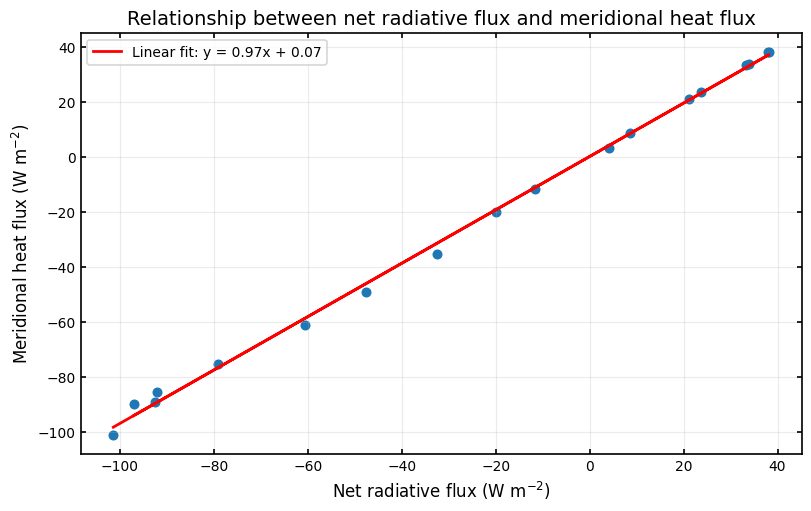

Root Mean Square Error (RMSE) between meridional heat flux and net radiative flux: 2.65 W m⁻²


In [54]:
# We can also quantify the relationship between the net radiative flux and the meridional heat transport by performing a linear fit 
coeffs = np.polyfit(sol_IR_net_flux_mean, F_flux_mean, deg=1)
a, b = coeffs
y_fit = a * sol_IR_net_flux_mean + b

# To evaluate the quality of the linear fit, we can calculate the coefficient of determination R²
correlation_matrix = np.corrcoef(sol_IR_net_flux_mean, F_flux_mean)
correlation_xy = correlation_matrix[0, 1]
r_squared = correlation_xy**2
print(f"Linear : y = {a:.2f}x + {b:.2f}, R² = {r_squared:.4f}")

fig, ax = plt.subplots()
ax.scatter(sol_IR_net_flux_mean, F_flux_mean, marker='o')
ax.plot(sol_IR_net_flux_mean, y_fit, label=f"Linear fit: y = {a:.2f}x + {b:.2f}", color='red')
ax.set_xlabel(r"Net radiative flux (W m$^{-2}$)")
ax.set_ylabel(r"Meridional heat flux (W m$^{-2}$)")
ax.set_title("Relationship between net radiative flux and meridional heat flux")
ax.legend()
fig.savefig(results_dir / "net_radiative_flux_vs_meridional_heat_flux.png")
plt.show()

# Root Mean Square Error (RMSE) between data points and the identity function (which would represent a perfect balance between net radiative flux and meridional heat flux)
rmse = np.sqrt(np.mean((F_flux_mean - sol_IR_net_flux_mean)**2))
print(f"Root Mean Square Error (RMSE) between meridional heat flux and net radiative flux: {rmse:.2f} W m⁻²")
